# Decision Trees from Scratch 🌳

In this notebook, we implement a **Decision Tree** using the **CART (Classification and Regression Trees)** algorithm for classification.

## 📖 Theoretical Background

A decision tree is a hierarchical structure where each internal node represents a 'test' on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label.

### 1. Gini Impurity
To decide where to split the data, we use **Gini Impurity**, which measures the frequency at which a randomly chosen element from a set would be incorrectly labeled.
$$Gini(p) = 1 - \sum_{i=1}^{J} p_i^2$$
Where $p_i$ is the probability of an item with label $i$ being chosen.

### 2. Information Gain / Impurity Reduction
The best split is the one that maximizes the reduction in impurity:
$$\Delta Gini = Gini(parent) - [w_{left} Gini(left) + w_{right} Gini(right)]$$

### 3. Recursive Partitioning
The algorithm works recursively:
1. Start with the entire dataset at the root.
2. Find the best feature and threshold to split the data.
3. Split the data into two subsets.
4. Repeat until a stopping criterion (max depth, min samples) is met.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Check stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find best split
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # Create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thresh in thresholds:
                gain = self._information_gain(y, X_column, thresh)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thresh

        return split_idx, split_thresh

    def _information_gain(self, y, X_column, thresh):
        # Parent Gini
        parent_gini = self._gini(y)

        # Generate split
        left_idxs, right_idxs = self._split(X_column, thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Weighted average of children Gini
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        gini_l, gini_r = self._gini(y[left_idxs]), self._gini(y[right_idxs])
        child_gini = (n_l/n) * gini_l + (n_r/n) * gini_r

        # Info gain is the reduction in impurity
        ig = parent_gini - child_gini
        return ig

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _gini(self, y):
        proportions = np.bincount(y) / len(y)
        return 1 - np.sum([p**2 for p in proportions if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 🧪 Data Generation and Training

In [3]:
# Generate moon-shaped data
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

clf = DecisionTree(max_depth=10)
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")

Decision Tree Accuracy: 90.00%


## 📊 Visualization

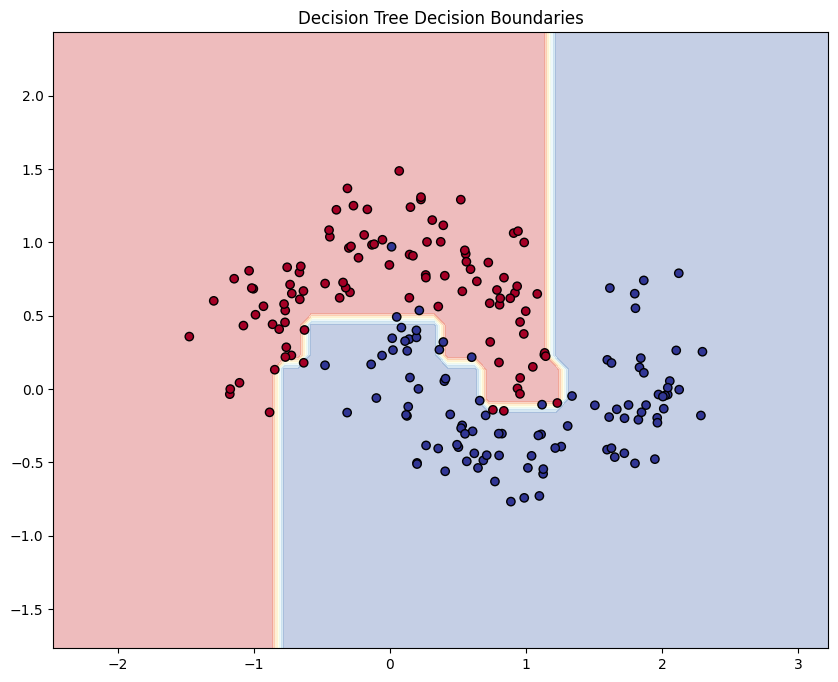

In [4]:
plt.figure(figsize=(10, 8))

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k')
plt.title("Decision Tree Decision Boundaries")
plt.show()